<a href="https://colab.research.google.com/github/maytediaz0226-debug/M-todos-num-ricos-2-/blob/main/Integracion_Romberg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

METODOS NUMERICOS II
<h1 style="font=family:Georgia;font-size:40px;">
INTEGRACION DE ROMBERG
</h1>
Nombre: Mayte Diaz Bojorges




<h1 style="font-family: Georgia;">
Introduccion
</h1>

<p style="font-family: Arial; font-size:17px; text-align:justify;">
La integración de Romberg es un método numérico que permite aproximar el valor
de una integral definida utilizando sucesivas aproximaciones de la regla
compuesta del trapecio y un proceso de extrapolación.
</p>

<p style="font-family: Arial; font-size:17px;">
Para este trabajo se utilizará como prueba el <b>Ejemplo 2
del libro de Burden</b>, donde se considera la integral:
</p>

$${I=\int_0^\pi \sin(x)\,dx}$$

<p style="font-family: Arial; font-size:17px;">
El objetivo es implementar en Python el <b>Algoritmo 4.2 </b>
y construir la tabla de Romberg fila por fila.
</p>

<h2 style="font-family: 'Trebuchet MS';">
Valor exacto de la integral
</h2>

<p style="font-family: Arial; font-size:17px;">
Antes de aplicar el método numérico, podemos calcular el valor exacto de la integral para posteriormente comparar el resultado obtenido.
</p>

$$I=\int_0^\pi \sin(x)\,dx$$

Como

$$\int \sin(x)\,dx=-\cos(x)$$

entonces

$$I=\left[-\cos(x)\right]_0^\pi$$

$$I=-\cos(\pi)-[-\cos(0)]$$

Como

$$\cos(\pi)=-1\qquad\text{y}\qquad\cos(0)=1$$

obtenemos

$$I=-(-1)-(-1)=2$$

Por lo tanto, el valor exacto es

$${I=2}$$

<h1 style="font-family: Georgia;">
Método de integración de Romberg
</h1>

<p style="font-family: Arial; font-size:17px; text-align:justify;">
El método de Romberg utiliza la regla compuesta del trapecio para obtener aproximaciones iniciales.
Posteriormente, estas aproximaciones son mejoradas
mediante extrapolación
</p>

<p style="font-family: Arial; font-size:17px;">
La primera aproximación se obtiene mediante:
</p>

$$R_{1,1}=\frac{h}{2}[f(a)+f(b)]$$

donde $h=b-a$

Para las siguientes filas se utiliza:

$$R_{i,1}=\frac{1}{2}\left[R_{i-1,1}+h\sum_{k=1}^{2^{i-2}}f\left(a+\left(k-\frac12\right)h\right)\right]$$

Después se aplica la extrapolación

$$R_{i,j}=R_{i,j-1}+\frac{R_{i,j-1}-R_{i-1,j-1}}{4^{j-1}-1}$$

<p style="font-family: Arial; font-size:17px;">
Finalmente, el tamaño del paso se reduce a la mitad
</p>

$$
h=\frac{h}{2}
$$

<p style="font-family: Arial; font-size:17px;">
De esta manera se construye la tabla de Romberg por filas.
</p>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [ ]:
def f(x):

    return np.sin(x)

In [ ]:
def romberg(f, a, b, n):

    R = np.zeros((n, n))

    h = b - a

    R[0, 0] = (h / 2) * (f(a) + f(b))

    for i in range(1, n):

        suma = 0

        for k in range(1, 2**(i-1) + 1):

            x = a + (k - 0.5) * h

            suma += f(x)

        R[i, 0] = 0.5 * (R[i-1, 0] + h * suma)

        for j in range(1, i + 1):

            R[i, j] = (
                R[i, j-1]
                + (R[i, j-1] - R[i-1, j-1])
                / (4**j - 1)
            )

        h = h / 2

    return R

<h1 style="font-family: Georgia;">
Ejemplo 2
</h1>

<p style="font-family: Arial; font-size:17px;">
Se aplicará el algoritmo a la integral:
</p>

$${\int_0^\pi \sin(x)\,dx}$$

<p style="font-family: Arial; font-size:17px;">
Por lo tanto
</p>

$$a=0$$

$$b=\pi$$

<p style="font-family: Arial; font-size:17px;">
Para reproducir la tabla mostrada en el ejemplo de Burden utilizaremos
</p>

$$n=6$$

In [ ]:
a = 0
b = math.pi
n = 6

R = romberg(f, a, b, n)

print("Tabla de Romberg:")
print(R)

Tabla de Romberg:
[[1.92367069e-16 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.57079633e+00 2.09439510e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.89611890e+00 2.00455975e+00 1.99857073e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.97423160e+00 2.00026917e+00 1.99998313e+00 2.00000555e+00
  0.00000000e+00 0.00000000e+00]
 [1.99357034e+00 2.00001659e+00 1.99999975e+00 2.00000002e+00
  1.99999999e+00 0.00000000e+00]
 [1.99839336e+00 2.00000103e+00 2.00000000e+00 2.00000000e+00
  2.00000000e+00 2.00000000e+00]]


<h2 style="font-family: 'Trebuchet MS';">
Resultados obtenidos
</h2>

<p style="font-family: Arial; font-size:17px;">
La tabla de Romberg obtenida mediante el programa es aproximadamente
</p>

$$
\begin{array}{c|cccccc}
 & & & & & &\\
R_{1,1} & 0 \\
R_{2,1} & 1.57079633 & 2.09439511\\
R_{3,1} & 1.89611890 & 2.00455975 & 1.99857073\\
R_{4,1} & 1.97423160 & 2.00026917 & 1.99998313 & 2.00000555\\
R_{5,1} & 1.99357034 & 2.00001659 & 1.99999975 & 2.00000002 & 1.99999999\\
R_{6,1} & 1.99839336 & 2.00000103 & 2.00000000 & 2.00000000 & 2.00000000 & 2.00000000
\end{array}
$$

<p style="font-family: Arial; font-size:17px;">
Se observa que las aproximaciones convergen rápidamente hacia el valor exacto de la integral
</p>

$$I=2 $$

In [ ]:
resultado = R[-1, -1]
valor_exacto = 2

error_absoluto = abs(valor_exacto - resultado)


print(f"Valor obtenido por Romberg : ",resultado)
print(f"Valor exacto               : ",valor_exacto)
print(f"Error absoluto             : ",error_absoluto)



Valor obtenido por Romberg :  2.000000000001321
Valor exacto               :  2
Error absoluto             :  1.3211653993039363e-12


<h1 style="font-family: Georgia;">
Gráfica
</h1>

<p style="font-family: Arial; font-size:17px;">
La siguiente gráfica representa la función
$ f(x)=\sin(x) $ en el intervalo $[0,\pi]$.
El área bajo la curva corresponde al valor de la integral.
</p>

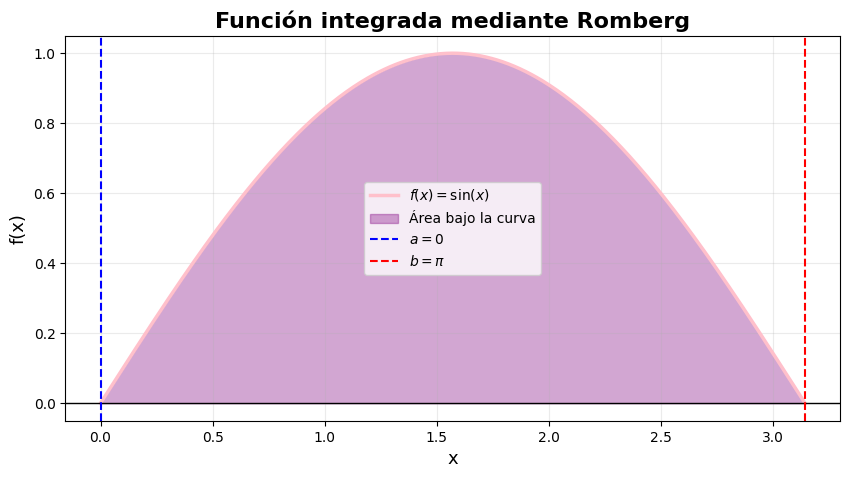

In [ ]:
x = np.linspace(a, b, 500)
y = f(x)

plt.figure(figsize=(10, 5))
plt.plot( x, y, color="pink",linewidth=2.5, label=r"$f(x)=\sin(x)$")

plt.fill_between(x,y,color="purple",alpha=0.35,label="Área bajo la curva")

plt.axhline( 0,color="black",linewidth=1)

plt.axvline( a, color="blue", linestyle="--",label=r"$a=0$")

plt.axvline( b,color="red",linestyle="--", label=r"$b=\pi$")

plt.title("Función integrada mediante Romberg",fontsize=16, fontweight="bold")

plt.xlabel("x", fontsize=13)
plt.ylabel("f(x)", fontsize=13)

plt.grid( True, alpha=0.25)

plt.legend()
plt.show()

<h2 style="font-family: 'Trebuchet MS';">
Convergencia del método
</h2>

<p style="font-family: Arial; font-size:17px;">
Para observar el comportamiento del método, podemos representar el valor de la última aproximación disponible de cada fila de Romberg.
</p>

<p style="font-family: Arial; font-size:17px;">
La línea horizontal representa el valor exacto
</p>

$$I=2$$

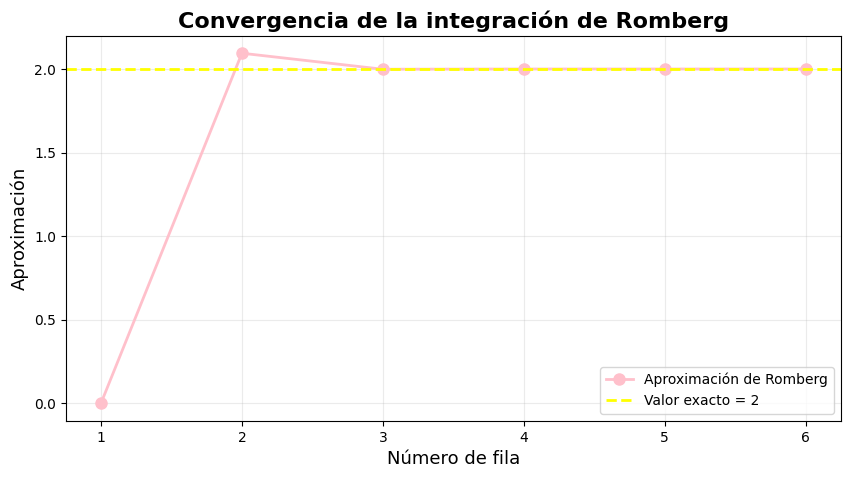

In [ ]:
filas = np.arange(1, n + 1)

aproximaciones = np.array([
    R[i, i] for i in range(n)
])

plt.figure(figsize=(10, 5))

plt.plot(filas,aproximaciones,marker="o",markersize=8, linewidth=2, color="pink",label="Aproximación de Romberg")

plt.axhline( 2, color="yellow", linestyle="--", linewidth=2, label="Valor exacto = 2")

plt.title("Convergencia de la integración de Romberg", fontsize=16, fontweight="bold")

plt.xlabel("Número de fila", fontsize=13)
plt.ylabel("Aproximación", fontsize=13)

plt.xticks(filas)

plt.grid( True,alpha=0.25)

plt.legend()
plt.show()

<p style="font-family: Arial; font-size:17px; text-align:justify;">
A partir de la tabla obtenida se observa que las aproximaciones mejoran conforme se incrementa el número de filas. La regla del trapecio proporciona la primera columna de la tabla y posteriormente la extrapolación de Richardson permite obtener aproximaciones cada vez más precisas.
</p>

<p style="font-family: Arial; font-size:17px; text-align:justify;">
En el ejemplo analizado, el valor exacto de la integral es
</p>

$$I=2$$

<p style="font-family: Arial; font-size:17px; text-align:justify;">
Mientras que la aproximación obtenida en la última entrada de la tabla es
</p>

$$R_{6,6}\approx2.00000000$$

<p style="font-family: Arial; font-size:17px; text-align:justify;">
La diferencia entre ambos valores es prácticamente cero, por lo que el algoritmo implementado reproduce correctamente el resultado esperado.
</p>

<h1 style="font-family: Georgia;">
Conclusión
</h1>

<p style="font-family: Arial; font-size:17px; text-align:justify;">
Se implementó en el método de integración de Romberg siguiendo el Algoritmo 4.2 presentado por Burden. El método parte de aproximaciones obtenidas mediante la regla compuesta del trapecio y utiliza posteriormente
extrapolación para aumentar la precisión.
</p>

<p style="font-family: Arial; font-size:17px; text-align:justify;">
Como prueba se utilizó el Ejemplo 2 de la página 160
</p>

$$\int_0^\pi \sin(x)\,dx$$

<p style="font-family: Arial; font-size:17px; text-align:justify;">
El valor exacto es 2 y el programa obtuvo:
</p>

$${R_{6,6}=2.00000000}$$

<p style="font-family: Arial; font-size:17px; text-align:justify;">
Por lo tanto, se verifica que la implementación del algoritmo es correcta y que el método de Romberg permite obtener aproximaciones de alta precisión con un número relativamente pequeño de filas.
</p>

</div>